<a href="https://colab.research.google.com/github/Andru-1987/data_science_ii_96085/blob/main/10_semana/clase_practica/AmesHousing_Practica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis de mejora de Machine Learning

In [64]:
import warnings
import numpy as np
import pandas as pd

from scipy import stats
from scipy.stats import skew, kurtosis

import seaborn as sns
import matplotlib.pyplot as plt



warnings.filterwarnings("ignore")


In [62]:
url = "https://gist.githubusercontent.com/Andru-1987/7f73d80371810da05e30ce0ce8e7696a/raw/f0420e511aa11bbd22faee319f1246b50e6d7b95/AmesHousing.csv"

df = pd.read_csv(url, encoding='utf8')
df.sample(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
608,609,534402140,20,RL,NaN,11000,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1966,1966,Gable,CompShg,Plywood,Plywood,BrkFace,200.0,TA,TA,CBlock,TA,TA,Mn,BLQ,740.0,Rec,230.0,184.0,1154.0,GasA,Ex,Y,SBrkr,1154,0,0,1154,0.0,0.0,1,1,3,1,TA,6,Typ,1,Po,Attchd,1966.0,RFn,2.0,480.0,TA,TA,Y,0,58,0,0,0,0,NaN,MnPrv,NaN,0,11,2009,WD,Normal,154000
728,729,903200080,70,RL,144.0,21384,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,BrkSide,Norm,Norm,1Fam,2Story,5,6,1923,2004,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,TA,TA,CBlock,TA,TA,Gd,GLQ,1309.0,Unf,0.0,15.0,1324.0,GasA,Ex,Y,SBrkr,1072,504,0,1576,2.0,0.0,1,1,3,1,Gd,6,Typ,1,TA,Attchd,1923.0,RFn,2.0,528.0,TA,TA,Y,0,312,0,0,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal,223500
1308,1309,902300215,50,RM,100.0,12665,Pave,Grvl,IR1,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,5,8,1915,1950,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,TA,TA,BrkTil,TA,TA,Mn,Unf,0.0,Unf,0.0,876.0,876.0,GasA,Gd,Y,SBrkr,876,540,0,1416,0.0,0.0,1,1,4,1,TA,7,Typ,1,Gd,Detchd,1949.0,Unf,3.0,720.0,TA,TA,Y,418,0,194,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,153900
1035,1036,527402130,20,RL,68.0,10295,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,NAmes,Norm,Norm,1Fam,1Story,4,6,1969,1969,Gable,CompShg,HdBoard,HdBoard,BrkFace,72.0,TA,TA,CBlock,Gd,TA,Mn,Rec,252.0,Unf,0.0,684.0,936.0,GasA,TA,Y,SBrkr,936,0,0,936,0.0,0.0,1,0,2,1,TA,4,Typ,0,NaN,Attchd,1969.0,Unf,1.0,288.0,TA,TA,Y,16,0,0,0,0,0,NaN,NaN,NaN,0,9,2008,COD,Normal,111900
1117,1118,528431120,60,RL,73.0,9801,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,2Story,8,5,2007,2007,Gable,CompShg,VinylSd,VinylSd,Stone,156.0,Gd,TA,PConc,Gd,TA,Av,Unf,0.0,Unf,0.0,1341.0,1341.0,GasA,Ex,Y,SBrkr,1341,520,0,1861,0.0,0.0,3,0,3,1,Gd,7,Typ,1,Gd,BuiltIn,2007.0,RFn,3.0,851.0,TA,TA,Y,144,60,0,0,0,0,NaN,NaN,NaN,0,7,2008,WD,Normal,257000
2087,2088,905480090,50,RL,50.0,7550,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1.5Fin,4,5,1920,1950,Gambrel,CompShg,MetalSd,MetalSd,NaN,0.0,Fa,Fa,BrkTil,TA,Fa,No,Unf,0.0,Unf,0.0,951.0,951.0,GasW,Fa,N,SBrkr,986,376,0,1362,0.0,0.0,2,0,4,1,TA,7,Typ,0,NaN,Detchd,1920.0,Unf,1.0,280.0,Fa,TA,P,0,0,0,0,0,0,NaN,MnPrv,NaN,0,3,2007,WD,Normal,96000
2409,2410,528188040,120,RL,NaN,3136,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NridgHt,Norm,Norm,TwnhsE,1Story,7,5,2003,2003,Gable,CompShg,VinylSd,Wd Shng,Stone,163.0,Gd,TA,PConc,Gd,TA,No,Unf,0.0,Unf,0.0,1405.0,1405.0,GasA,Ex,Y,SBrkr,1405,0,0,1405,0.0,0.0,2,0,2,1,Gd,6,Typ,1,Gd,Attchd,2003.0,RFn,2.0,478.0,TA,TA,Y,148,36,0,0,0,0,NaN,NaN,NaN,0,3,2006,WD,Normal,171750
54,55,528231020,80,RL,67.0,13300,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,SLvl,7,5,2004,2004,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,Gd,TA,PConc,Gd,TA,No,GLQ,326.0,Unf,0.0,58.0,384.0,GasA,Ex,Y,SBrkr,744,630,0,1374,1.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,BuiltIn,2004.0,Fin,2.0,400.0,TA,TA,Y,100,0,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal,184500
676,677,535450160,90,RL,60.0,8544,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,Duplex,1Story,3,4,1950,1950,Gable,CompShg,BrkFace,BrkFace,NaN,0.0,TA,TA,Slab,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,W

## Data Cleaning

In [66]:
print("Shape:", df.shape)
df.info()

Shape: (2930, 82)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 

In [68]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order,2930.0,1.465500e+03,8.459625e+02,1.0,7.332500e+02,1465.5,2.197750e+03,2.930000e+03
PID,2930.0,7.144645e+08,1.887308e+08,526301100.0,5.284770e+08,535453620.0,9.071811e+08,1.007100e+09
MS SubClass,2930.0,5.738737e+01,4.263802e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2440.0,6.922459e+01,2.336533e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2930.0,1.014792e+04,7.880018e+03,1300.0,7.440250e+03,9436.5,1.155525e+04,2.152450e+05
Overall Qual,2930.0,6.094881e+00,1.411026e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2930.0,5.563140e+00,1.111537e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2930.0,1.971356e+03,3.024536e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2930.0,1.984267e+03,2.086029e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2907.0,1.018968e+02,1.791126e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03


In [67]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order,2930.0,NaN,NaN,NaN,1465.5,845.96247,1.0,733.25,1465.5,2197.75,2930.0
PID,2930.0,NaN,NaN,NaN,714464496.988737,188730844.64939,526301100.0,528477022.5,535453620.0,907181097.5,1007100110.0
MS SubClass,2930.0,NaN,NaN,NaN,57.387372,42.638025,20.0,20.0,50.0,70.0,190.0
MS Zoning,2930,7,RL,2273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lot Frontage,2440.0,NaN,NaN,NaN,69.22459,23.365335,21.0,58.0,68.0,80.0,313.0
...,...,...,...,...,...,...,...,...,...,...,...
Mo Sold,2930.0,NaN,NaN,NaN,6.216041,2.714492,1.0,4.0,6.0,8.0,12.0
Yr Sold,2930.0,NaN,NaN,NaN,2007.790444,1.316613,2006.0,2007.0,2008.0,2009.0,2010.0
Sale Type,2930,10,WD,2536,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sale Condition,2930,6,Normal,2413,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:

from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score,
    RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 200)

In [75]:
limites = [0,10,20,50,100]
labels = ['Nullish Treatment','Nullish Treatment -> Complejidad', 'Alta complejidad y criterio con Negocio', 'Critico -> Posible eliminacion']

count = df.isnull().sum()
percent = df.isnull().mean() * 100

# Combine into a single DataFrame
missing_df = pd.concat([count, percent], axis=1, keys=['faltantes', 'porcentaje'])

# Filter for columns with missing values and sort
missing_df = missing_df[missing_df['faltantes'] > 0].sort_values('faltantes', ascending=False)

missing_df


missing_df["importancia_tratamiento"] = pd.cut(
    missing_df['porcentaje'], bins=limites, labels=labels,
    include_lowest=True, right=False
)

missing_df


,faltantes,porcentaje,importancia_tratamiento
Pool QC,2917,99.556314,Critico -> Posible eliminacion
Misc Feature,2824,96.382253,Critico -> Posible eliminacion
Alley,2732,93.242321,Critico -> Posible eliminacion
Fence,2358,80.477816,Critico -> Posible eliminacion
Mas Vnr Type,1775,60.580205,Critico -> Posible eliminacion
Fireplace Qu,1422,48.532423,Alta complejidad y criterio con Negocio
Lot Frontage,490,16.723549,Nullish Treatment -> Complejidad
Garage Qual,159,5.426621,Nullish Treatment
Garage Cond,159,5.426621,Nullish Treatment
Garage Yr Blt,159,5.426621,Nullish Treatment


Muchos NA no son errores: significan “no tiene sótano”, “no tiene garaje”, “no tiene piscina”, etc.
Por eso, en columnas como Pool QC, Alley, Fence, Fireplace Qu, Garage Type, Bsmt Qual, se debe imputar como "None" o "Missing", no con la media.

## Data Exploratory

#### Variable Objetivo

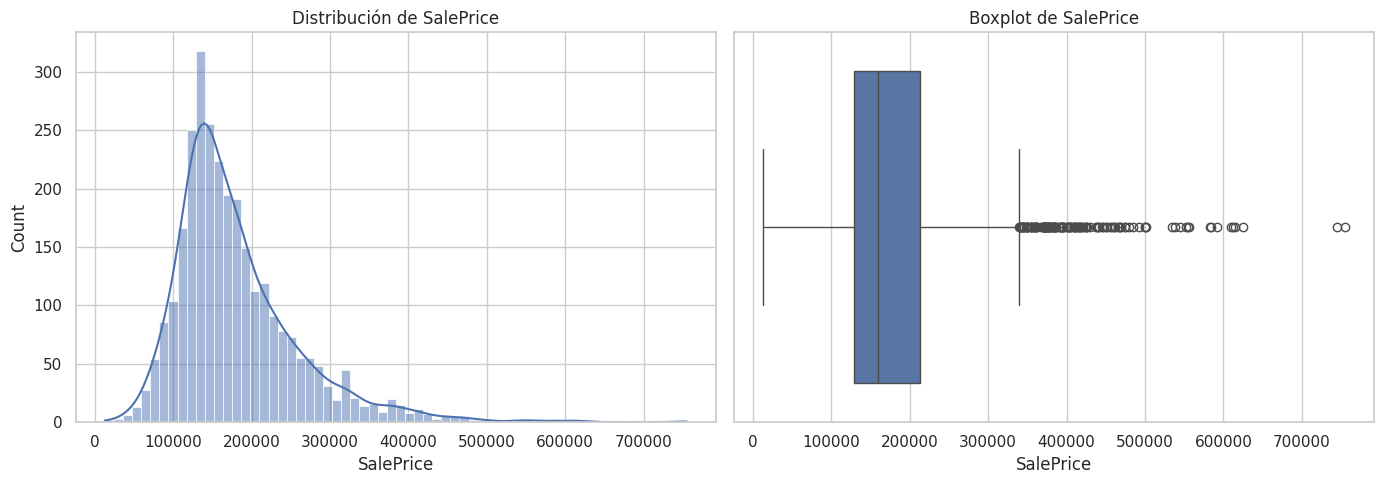

Skewness SalePrice: 1.7426073719460107
Kurtosis SalePrice: 5.108121716933333


In [77]:
target = 'SalePrice'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[target], kde=True, ax=axes[0])
axes[0].set_title("Distribución de SalePrice")

sns.boxplot(x=df[target], ax=axes[1])
axes[1].set_title("Boxplot de SalePrice")

plt.tight_layout()
plt.show()

print("Skewness SalePrice:", skew(df[target]))
print("Kurtosis SalePrice:", kurtosis(df[target]))

SalePrice tiene sesgo positivo fuerte y curtosis alta.
Para modelar, conviene usar log1p(SalePrice). O tratar de analizar si existe la posibilidad de eliminar los outilers, sin embargo por ahora lo vamos a dejar como Q&D Models

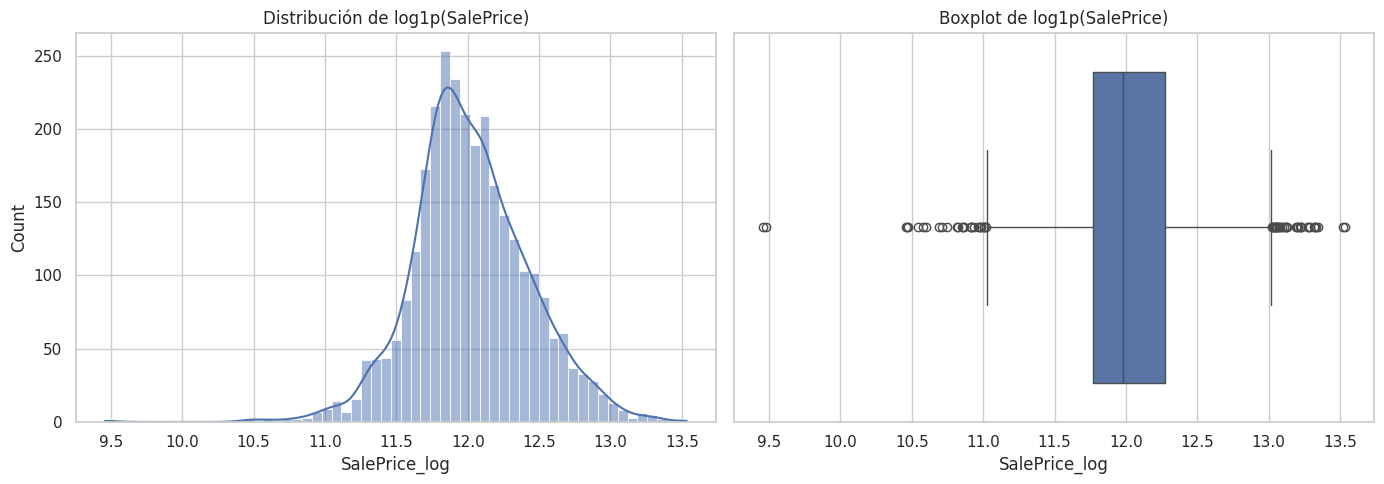

Skewness log(SalePrice): -0.014765095666499651
Kurtosis log(SalePrice): 1.5091889366122242


In [78]:
df["SalePrice_log"] = np.log1p(df[target])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["SalePrice_log"], kde=True, ax=axes[0])
axes[0].set_title("Distribución de log1p(SalePrice)")

sns.boxplot(x=df["SalePrice_log"], ax=axes[1])
axes[1].set_title("Boxplot de log1p(SalePrice)")
plt.tight_layout()
plt.show()

print("Skewness log(SalePrice):", skew(df["SalePrice_log"]))
print("Kurtosis log(SalePrice):", kurtosis(df["SalePrice_log"]))

---

### Variables Numericas

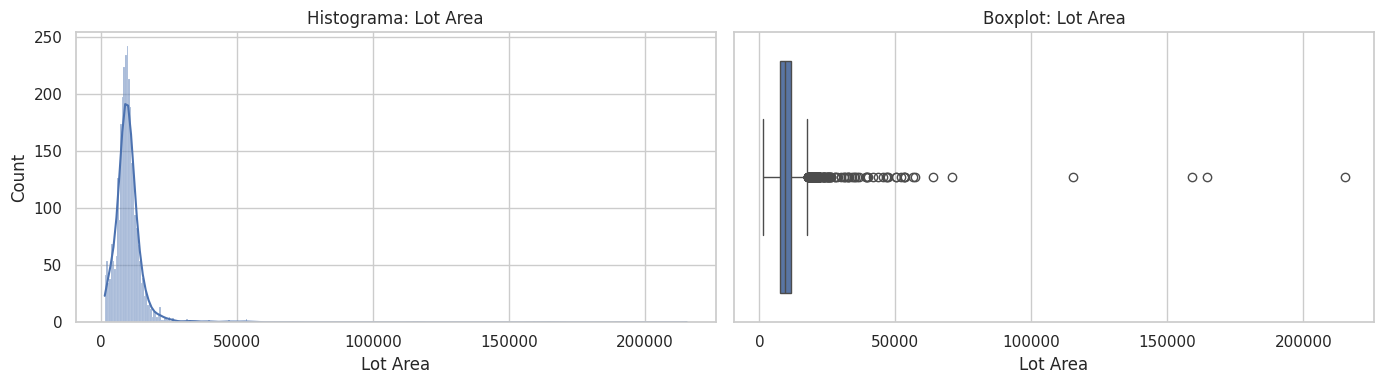

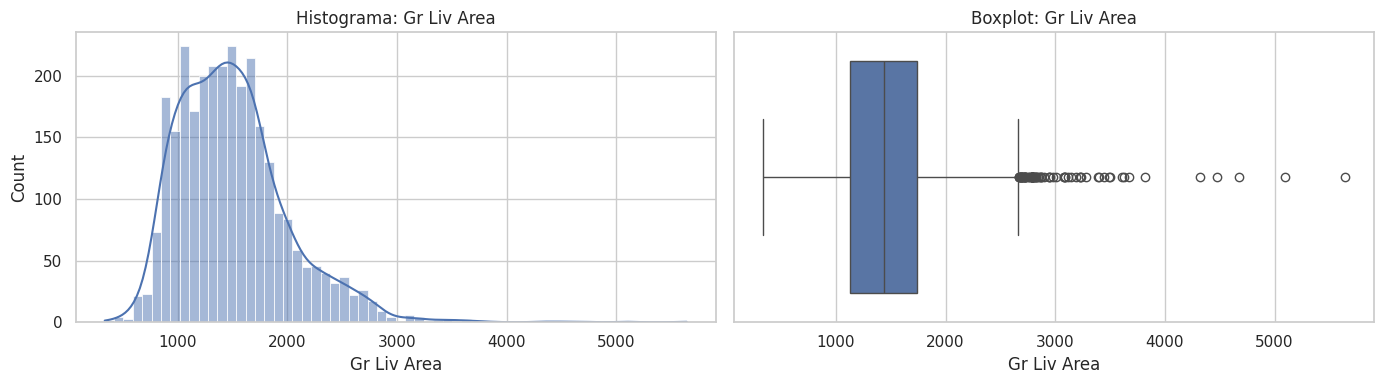

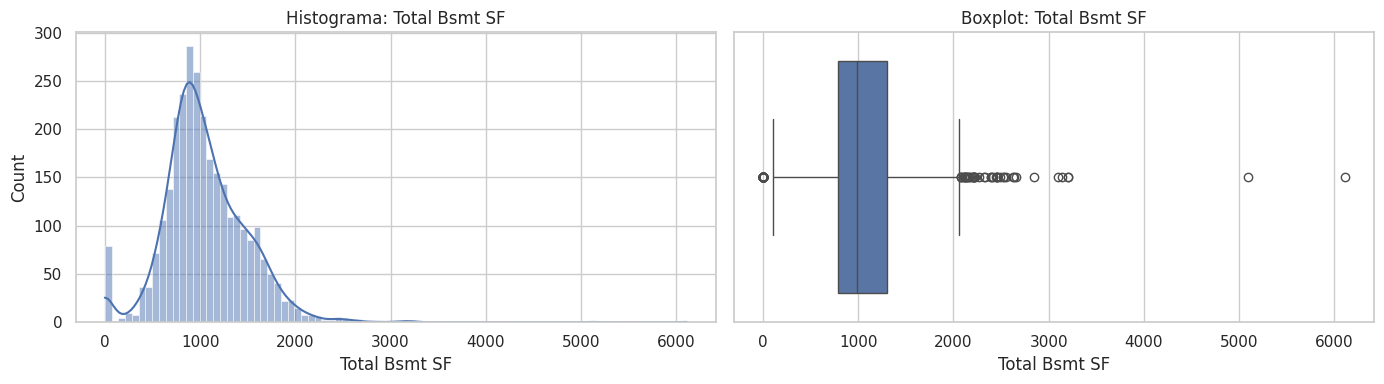

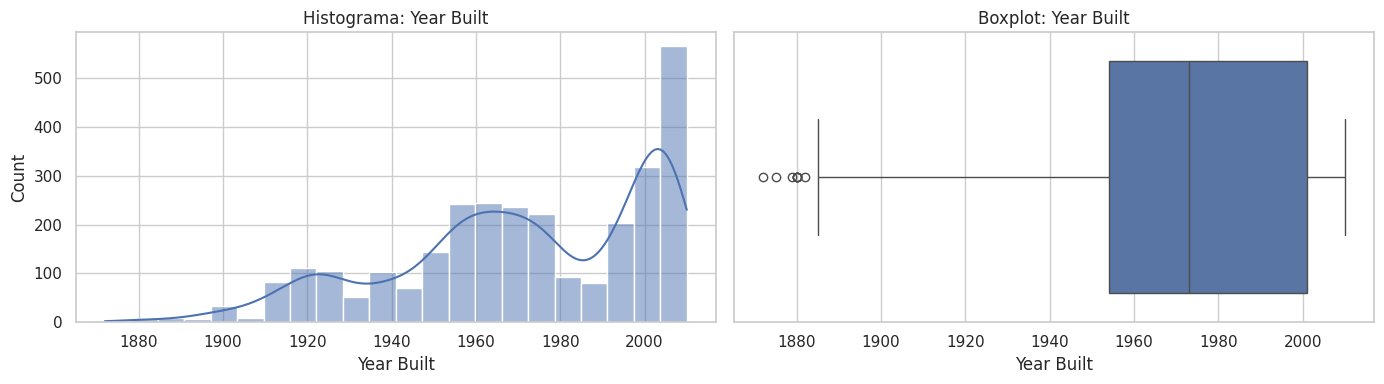

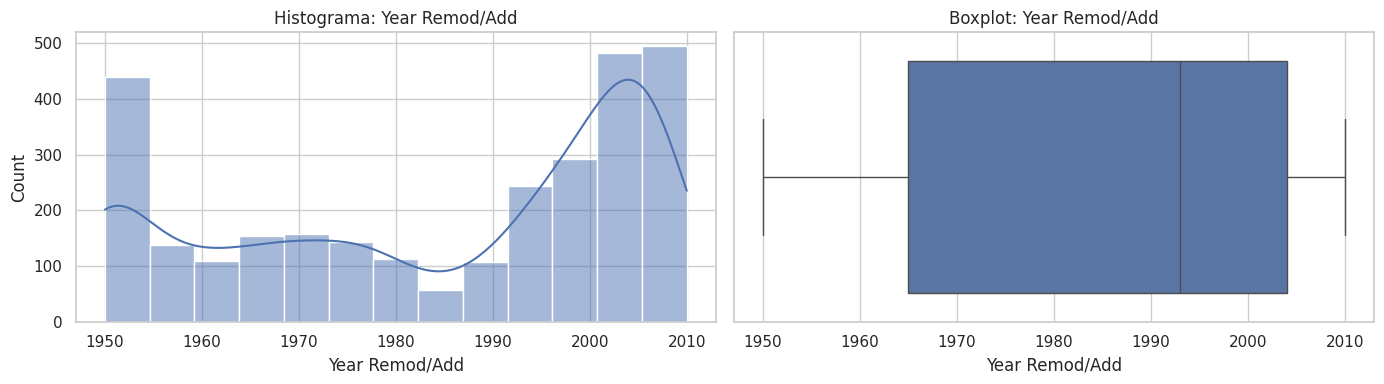

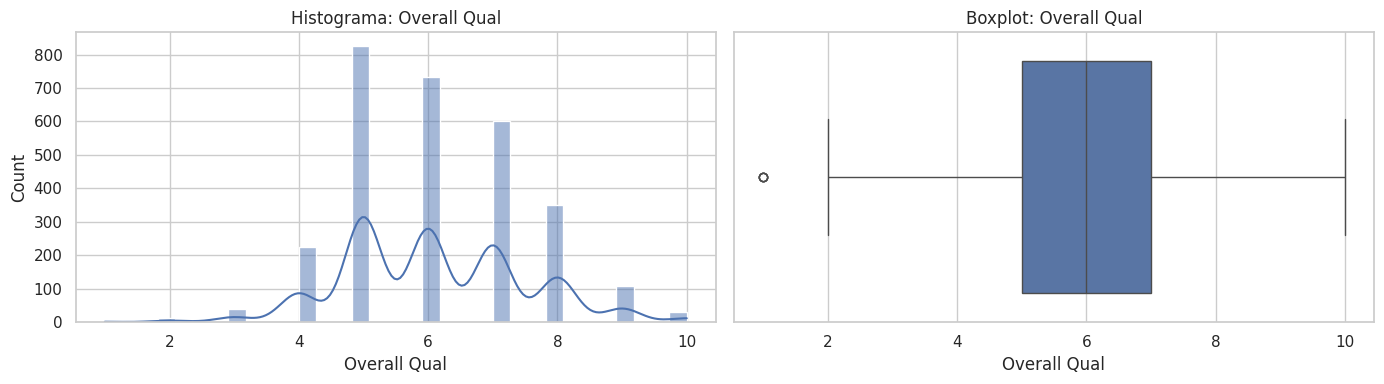

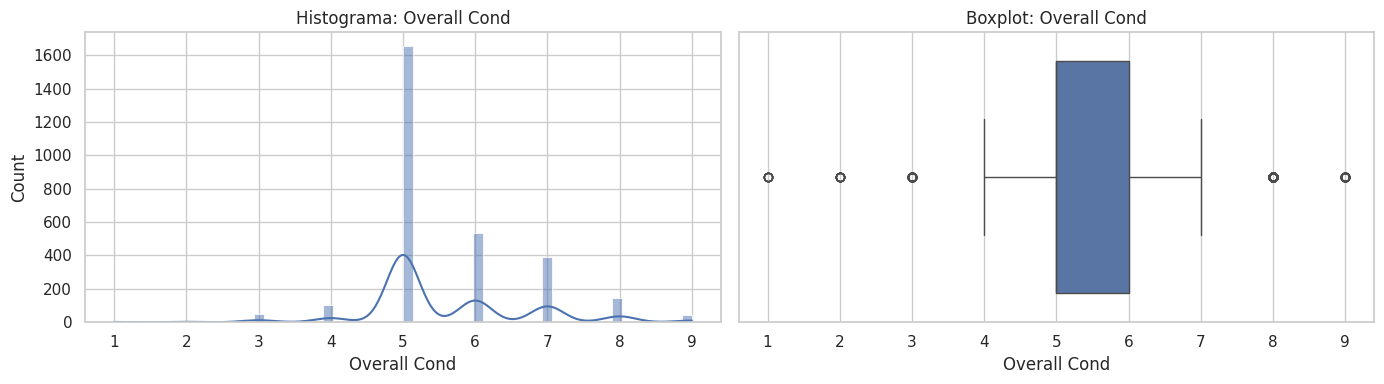

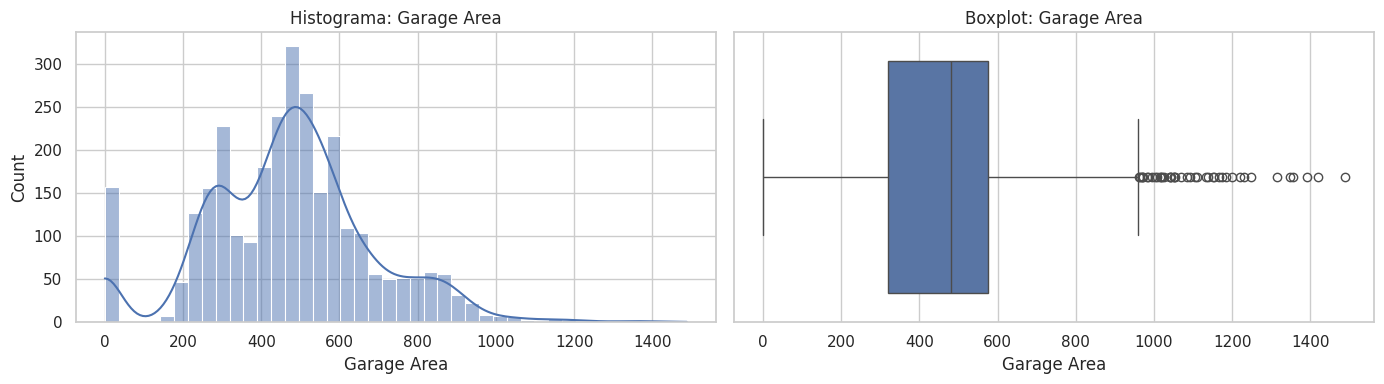

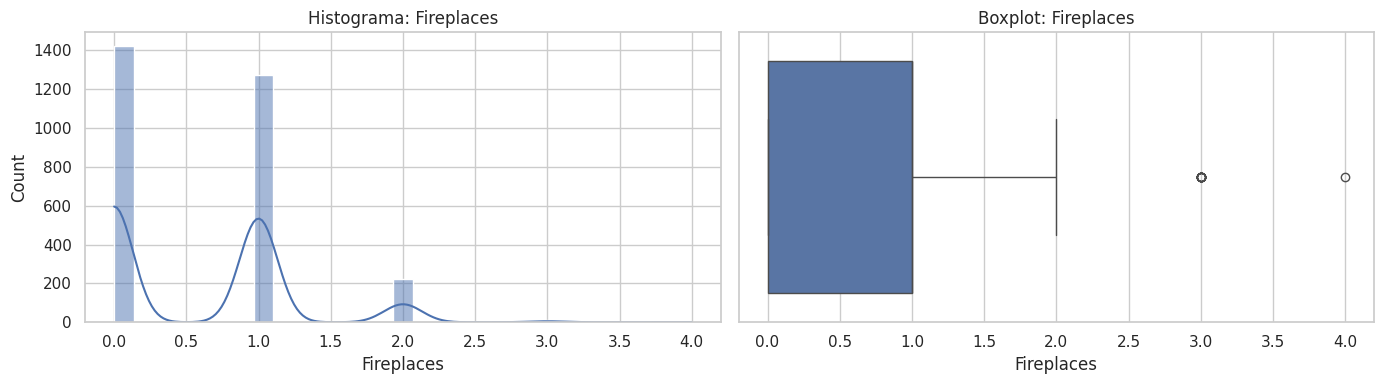

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

cols_interes = [
    "Lot Area", "Gr Liv Area", "Total Bsmt SF",
    "Year Built", "Year Remod/Add", "Overall Qual",
    "Overall Cond", "Garage Area", "Fireplaces"
]

for col in cols_interes:
    if col in df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        sns.histplot(df[col].dropna(), kde=True, ax=axes[0])
        axes[0].set_title(f"Histograma: {col}")
        sns.boxplot(x=df[col].dropna(), ax=axes[1])
        axes[1].set_title(f"Boxplot: {col}")
        plt.tight_layout()
        plt.show()

### Variables Categoricas

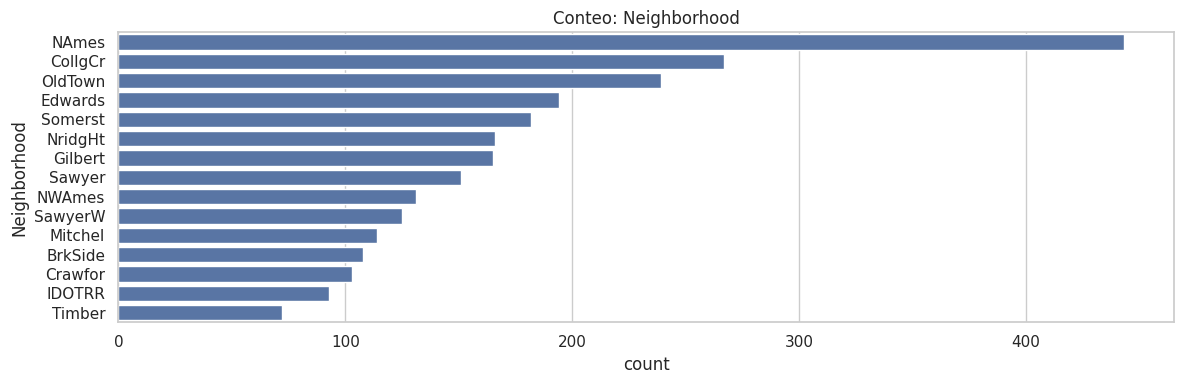

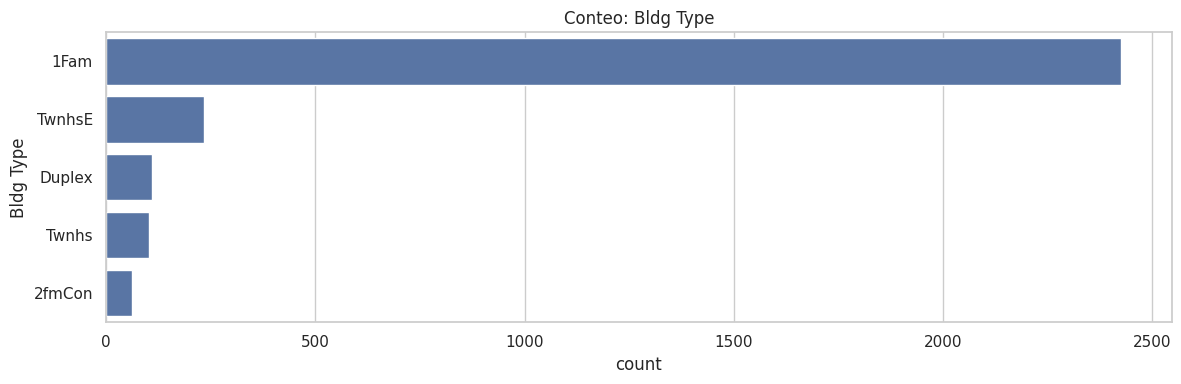

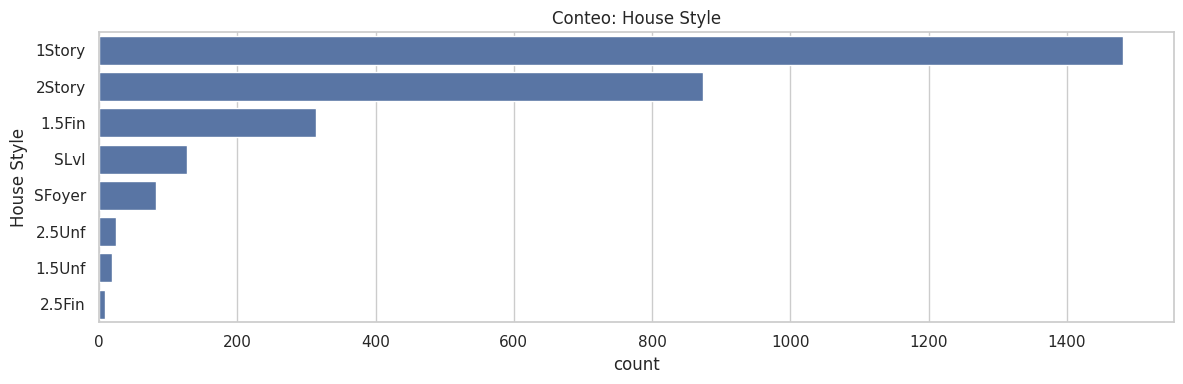

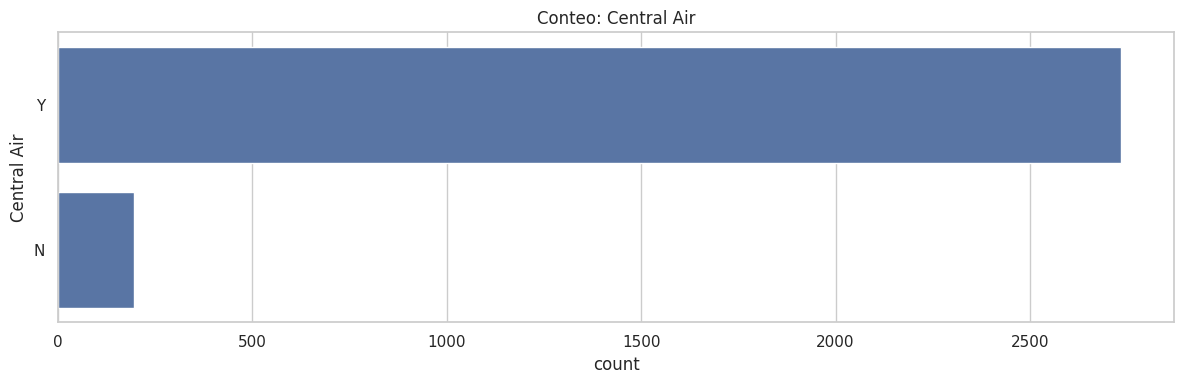

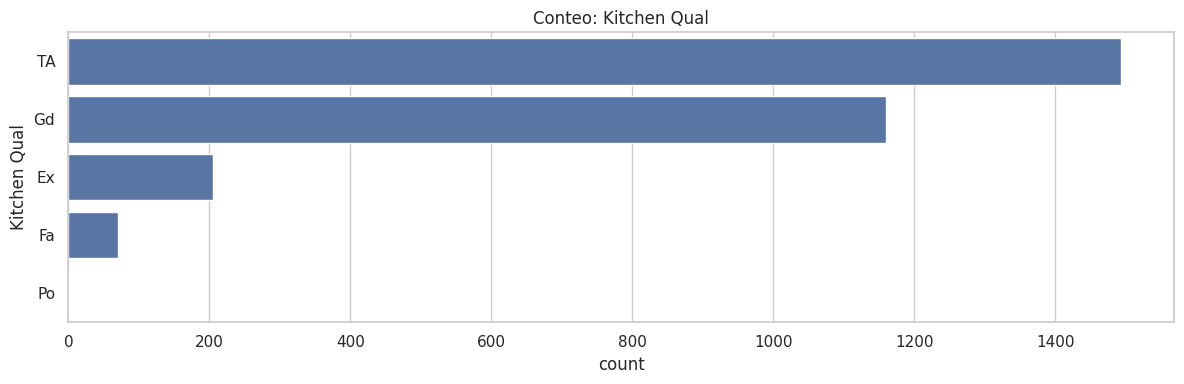

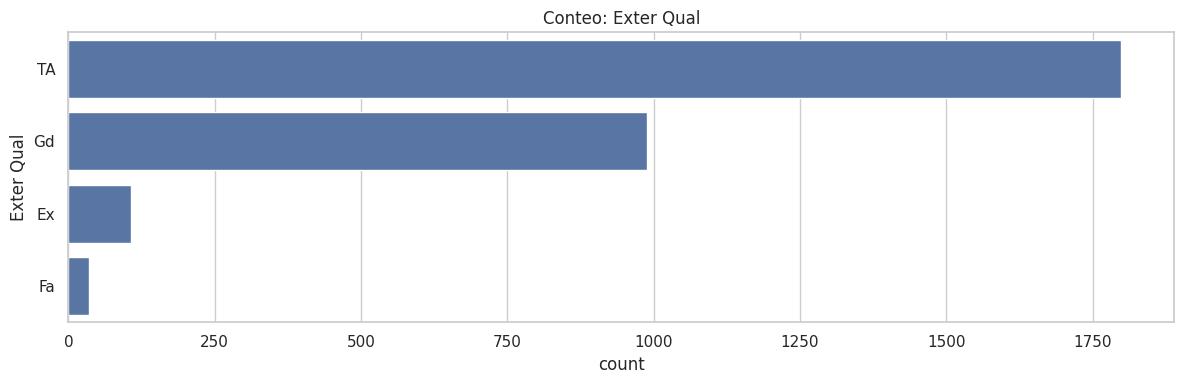

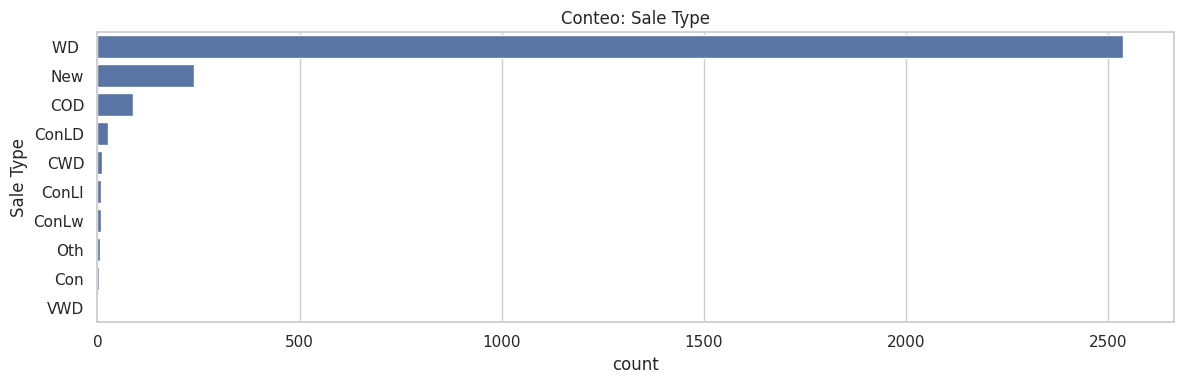

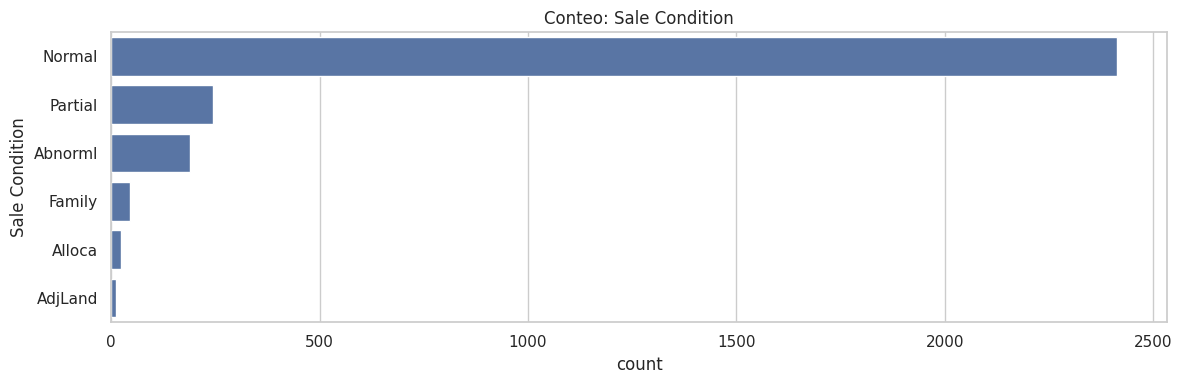

In [79]:
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

cat_interes = [
    "Neighborhood", "Bldg Type", "House Style",
    "Central Air", "Kitchen Qual", "Exter Qual",
    "Sale Type", "Sale Condition"
]

for col in cat_interes:
    if col in df.columns:
        plt.figure(figsize=(12, 4))
        order = df[col].value_counts().head(15).index
        sns.countplot(data=df, y=col, order=order)
        plt.title(f"Conteo: {col}")
        plt.tight_layout()
        plt.show()

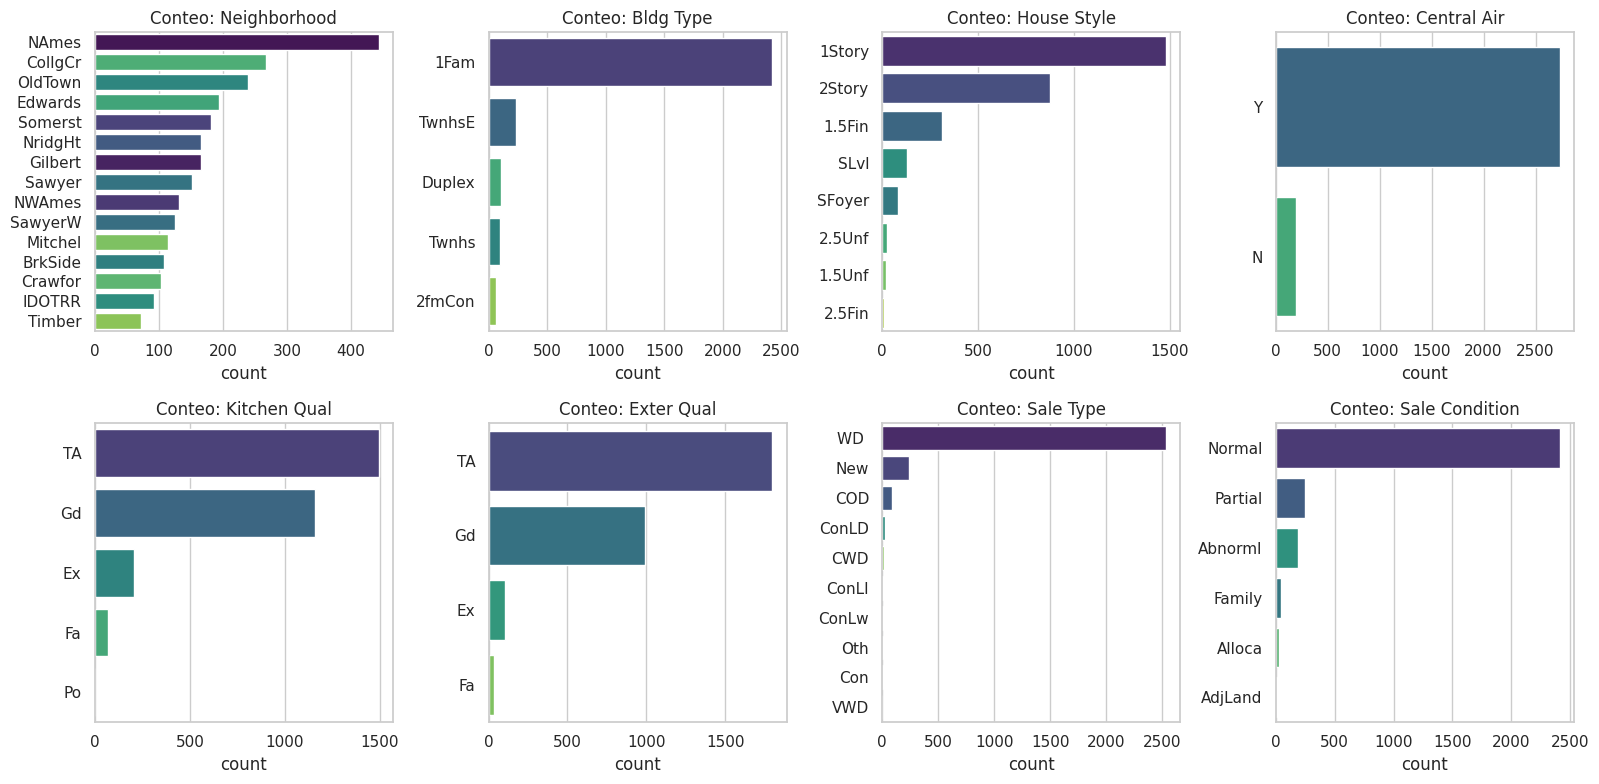

In [81]:
import math

cat_interes = [
    "Neighborhood", "Bldg Type", "House Style",
    "Central Air", "Kitchen Qual", "Exter Qual",
    "Sale Type", "Sale Condition"
]

# 1. Filtrar solo las columnas que realmente existen en el DataFrame
columnas_validas = [col for col in cat_interes if col in df.columns]

# 2. Configurar las dimensiones del grid (2 columnas, filas dinámicas)
n_cols = 4
n_rows = math.ceil(len(columnas_validas) / n_cols)

# 3. Crear la figura y los "axes" (la cuadrícula)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten() # Aplanamos el array 2D a 1D para iterar fácilmente

# 4. Iterar sobre las columnas y los axes simultáneamente
for i, col in enumerate(columnas_validas):
    orden = df[col].value_counts().head(15).index

    # Dibujar en el 'ax' correspondiente (axes[i])
    sns.countplot(
        data=df,
        y=col,
        order=orden,
        ax=axes[i],
        hue=col,         # Evita FutureWarnings en versiones nuevas de Seaborn
        legend=False,
        palette="viridis" # Opcional: le da color
    )

    axes[i].set_title(f"Conteo: {col}")
    axes[i].set_ylabel("") # Limpiamos el texto del eje Y para que se vea más ordenado

# 5. Eliminar los subgráficos vacíos (si el número de columnas es impar)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajustar el espaciado y mostrar
plt.tight_layout()
plt.show()

In [82]:
# Interpretación: Pool QC, Alley, Fence, Misc Feature, Garage * => "no tiene"
cols_no_tiene = ["Pool QC", "Alley", "Fence", "Misc Feature",
                 "Garage Type", "Garage Finish", "Garage Qual", "Garage Cond",
                 "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure",
                 "BsmtFin Type 1", "BsmtFin Type 2",
                 "Fireplace Qu", "Mas Vnr Type"]

# Confirmar que esos NaN no implican áreas > 0
for c in ["Pool QC", "Alley", "Fence"]:
    print(c, "->", df.loc[df[c].isna(),
          ["Pool Area" if c=="Pool QC" else "Lot Area" if c=="Alley" else "Lot Area"]].describe().loc[["mean","max"]])

# Único faltante real relevante
print("Lot Frontage NaN:", df["Lot Frontage"].isna().sum())   # 490

Pool QC ->       Pool Area
mean        0.0
max         0.0
Alley ->            Lot Area
mean   10341.545388
max   215245.000000
Fence ->            Lot Area
mean   10284.368957
max   215245.000000
Lot Frontage NaN: 490


In [83]:
def dist_table(col):
    s = df[col].dropna()
    return {
        "skew": skew(s),
        "kurtosis_exceso": kurtosis(s),   # scipy ya devuelve exceso (Fisher)
        "mean": s.mean(),
        "median": s.median(),
        "std": s.std()
    }

# Tabla exacta de tu archivo
tabla = pd.DataFrame({
    "SalePrice":        dist_table("SalePrice"),
    "log(SalePrice)":   dist_table("SalePrice_log"),
    "Misc Val":         dist_table("Misc Val"),
    "Pool Area":        dist_table("Pool Area"),
    "Lot Area":         dist_table("Lot Area"),
    "Low Qual Fin SF":  dist_table("Low Qual Fin SF"),
    "3Ssn Porch":       dist_table("3Ssn Porch"),
}).T[["skew", "kurtosis_exceso"]]

display(tabla.round(3))

,skew,kurtosis_exceso
SalePrice,1.743,5.108
log(SalePrice),-0.015,1.509
Misc Val,21.989,565.235
Pool Area,16.930,299.262
Lot Area,12.814,264.570
Low Qual Fin SF,12.112,175.305
3Ssn Porch,11.398,149.731


Mediana SalePrice: 160000.0
Media   SalePrice: 180796.0600682594


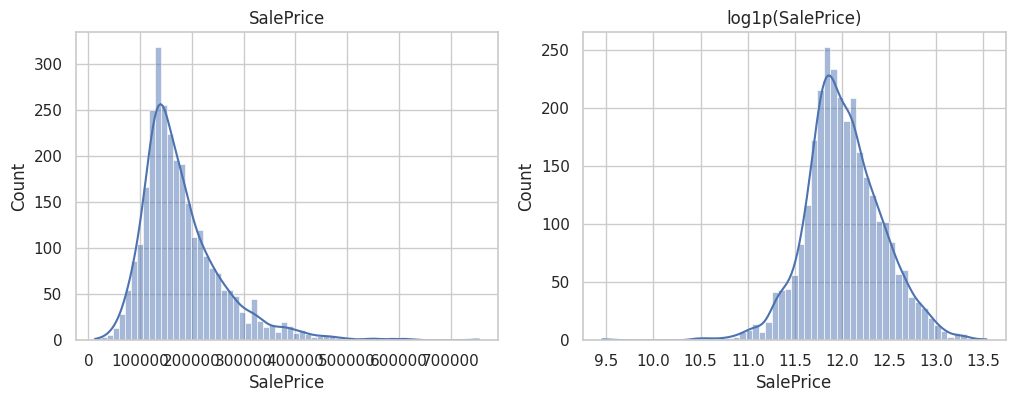

In [ ]:
print("Mediana SalePrice:", df["SalePrice"].median())   # 160000
print("Media   SalePrice:", df["SalePrice"].mean())     # 180796

# Visual
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df["SalePrice"], kde=True, ax=ax[0]); ax[0].set_title("SalePrice")
sns.histplot(np.log1p(df["SalePrice"]), kde=True, ax=ax[1]); ax[1].set_title("log1p(SalePrice)")
plt.show()

# Conclusión: se modela log(SalePrice)
df["SalePrice_log"] = np.log1p(df["SalePrice"])

# Aplicar log1p a variables sesgadas
for c in ["Lot Area", "Gr Liv Area", "Total Bsmt SF", "1st Flr SF"]:
    if c in df.columns:
        df[f"log_{c}"] = np.log1p(df[c])

### Correlacion de Spearman

In [85]:
target = "SalePrice_log"

spearman = (
    df.select_dtypes(include=np.number)
      .corr(method="spearman", numeric_only=True)[target]
      .drop(target)
      .sort_values(ascending=False)
)

top = spearman.head(10)
top

# Overall Qual ~0.81, Gr Liv Area ~0.72, Garage Cars ~0.70, Year Built ~0.68

,SalePrice_log
SalePrice,1.000000
Overall Qual,0.808800
Gr Liv Area,0.723342
Garage Cars,0.701813
Year Built,0.680822
Garage Area,0.660676
Garage Yr Blt,0.637674
Full Bath,0.634161
Total Bsmt SF,0.606184
Year Remod/Add,0.601454


In [86]:
out = df[df["Gr Liv Area"] > 4000][
    ["Gr Liv Area", "SalePrice", "Sale Condition", "Neighborhood", "Overall Qual"]
].sort_values("Gr Liv Area", ascending=False)

display(out)

# Filtro: 3 Partial en Edwards (160-185k) + 2 NoRidge (745k, 755k) = 5 filas
print("N outliers:", len(out))

# Decisión: eliminar los 5
mask_out = df["Gr Liv Area"] > 4000
df_clean = df.loc[~mask_out].copy()
print("Filas antes:", len(df), "-> después:", len(df_clean))

,Gr Liv Area,SalePrice,Sale Condition,Neighborhood,Overall Qual
1498,5642,160000,Partial,Edwards,10
2180,5095,183850,Partial,Edwards,10
2181,4676,184750,Partial,Edwards,10
1760,4476,745000,Abnorml,NoRidge,10
1767,4316,755000,Normal,NoRidge,10


N outliers: 5
Filas antes: 2930 -> después: 2925


In [ ]:
# R² de un one-way: varianza explicada por barrio sobre log-precio
grand_mean = df_clean["SalePrice_log"].mean()
group_means = df_clean.groupby("Neighborhood")["SalePrice_log"].transform("mean")
ss_between = ((group_means - grand_mean) ** 2).sum()
ss_total   = ((df_clean["SalePrice_log"] - grand_mean) ** 2).sum()
r2_neigh = ss_between / ss_total
print(f"R² Neighborhood ≈ {r2_neigh:.3f}")   # ~0.58

R² Neighborhood ≈ 0.582


In [87]:
df_clean["price_per_sf"] = df_clean["SalePrice"] / df_clean["Gr Liv Area"]

ppsf = (df_clean.groupby("Neighborhood")["price_per_sf"]
        .median().sort_values())

display(ppsf.head(5))    # SWISU, MeadowV, IDOTRR ~85
display(ppsf.tail(5))    # NridgHt, Greens, GrnHill ~160-199

,price_per_sf
Neighborhood,
SWISU,84.587224
MeadowV,86.101695
IDOTRR,87.246180
OldTown,92.532468
BrDale,94.813269


,price_per_sf
Neighborhood,
Timber,141.817341
StoneBr,157.864524
NridgHt,160.362880
Greens,170.269168
GrnHill,198.656617


In [88]:
display(df_clean.groupby("Central Air")["SalePrice"].median())
# N: 98250   Y: 166250

,SalePrice
Central Air,
N,98250.0
Y,166000.0


In [89]:
display(df_clean.groupby("Sale Condition")["SalePrice"].median().sort_values(ascending=False))
# Partial ~250k, Normal ~158.75k, Abnorml ~129k

,SalePrice
Sale Condition,
Partial,250290.0
Normal,158750.0
Alloca,149617.0
Family,144400.0
Abnorml,129000.0
AdjLand,110000.0


In [90]:
df_clean["Age"] = df_clean["Yr Sold"] - df_clean["Year Built"]

print("Corr Age vs log(SalePrice):",
      df_clean[["Age","SalePrice_log"]].corr().iloc[0,1])   # ~ -0.62

Corr Age vs log(SalePrice): -0.6172823341451543


### Analisis Multivariado

In [ ]:
pares = [("Year Built","Age"),
         ("Garage Cars","Garage Area"),
         ("Gr Liv Area","TotRms AbvGrd")]

for a,b in pares:
    print(f"{a} ↔ {b}: r = {df_clean[[a,b]].corr().iloc[0,1]:.3f}")
# 0.999, 0.89, 0.81

Year Built ↔ Age: r = -0.999
Garage Cars ↔ Garage Area: r = 0.892
Gr Liv Area ↔ TotRms AbvGrd: r = 0.809


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_cols = ["Overall Qual","Gr Liv Area","Garage Cars","Garage Area",
            "Year Built","Total Bsmt SF","1st Flr SF","Full Bath","TotRms AbvGrd"]

X_vif = df_clean[vif_cols].dropna()
X_vif = (X_vif - X_vif.mean()) / X_vif.std()   # estandarizar
X_vif["const"] = 1.0

vif = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

display(vif)
# Garage Cars ≈ 5.7 (máximo)

,variable,VIF
2,Garage Cars,5.669077
3,Garage Area,5.242948
1,Gr Liv Area,4.762483
6,1st Flr SF,3.117982
8,TotRms AbvGrd,3.066578
5,Total Bsmt SF,3.063435
0,Overall Qual,2.524976
7,Full Bath,2.107429
4,Year Built,2.037103
9,const,1.000000


### Paradoja de Simpson

In [ ]:
bins   = [0, 10, 30, 60, np.inf]
labels = ["0-10", "11-30", "31-60", ">60"]
df_clean["Age_bin"] = pd.cut(df_clean["Age"], bins=bins, labels=labels)

# Global
print("Global Overall Cond vs log(SalePrice):",
      df_clean[["Overall Cond","SalePrice_log"]].corr().iloc[0,1])   # ~ -0.05

# Por tramo
tabla_simpson = (df_clean.groupby("Age_bin")
                 .apply(lambda d: d[["Overall Cond","SalePrice_log"]].corr().iloc[0,1])
                 .rename("corr"))
display(tabla_simpson)
# 0-10: -0.07 | 11-30: -0.09 | 31-60: +0.32 | >60: +0.48

# Dentro de barrios (media ponderada de correlaciones dentro de cada barrio)
def corr_within(d, x, y):
    if d[x].nunique() < 2: return np.nan
    return d[[x,y]].corr().iloc[0,1]

corrs_neigh = (df_clean.groupby("Neighborhood")
               .apply(lambda d: corr_within(d, "Overall Cond", "SalePrice_log"))
               .dropna())
print("Media dentro de barrios:", corrs_neigh.mean())   # ~ +0.14

# Dentro de décadas
df_clean["Decade"] = (df_clean["Year Built"] // 10) * 10
corrs_dec = (df_clean.groupby("Decade")
             .apply(lambda d: corr_within(d, "Overall Cond", "SalePrice_log"))
             .dropna())
print("Media dentro de décadas:", corrs_dec.mean())     # ~ +0.17

Global Overall Cond vs log(SalePrice): -0.04831913575991588


,corr
Age_bin,
0-10,-0.060054
11-30,-0.091817
31-60,0.316416
>60,0.484381


Media dentro de barrios: 0.14222054051105898
Media dentro de décadas: 0.2419276968635362


### Inversion del signo

In [ ]:
def scan_simpson(df, x, y, group, umbral=0.05, min_n=20):
    sub = df[[x,y,group]].dropna()
    g = stats.linregress(sub[x], sub[y]).slope
    rows = []
    for k, d in sub.groupby(group):
        if len(d) >= min_n and d[x].nunique() > 1:
            rows.append((k, len(d), stats.linregress(d[x], d[y]).slope))
    if not rows: return None
    o = pd.DataFrame(rows, columns=["grupo","n","slope"])
    w = np.average(o["slope"], weights=o["n"])
    flag = np.sign(g) != np.sign(w) and abs(w - g) > umbral
    return {"x":x, "global":g, "weighted":w, "flag":flag}

# Ejemplo: Enclosed Porch → Neighborhood
print(scan_simpson(df_clean, "Enclosed Porch", "SalePrice_log", "Neighborhood"))
# flag=True → detectado por escaneo

# Overall Cond
print(scan_simpson(df_clean, "Overall Cond", "SalePrice_log", "Age_bin"))
# flag=False (queda debajo del umbral) → análisis manual

{'x': 'Enclosed Porch', 'global': np.float64(-0.0008995645245065137), 'weighted': np.float64(4.7894593299736596e-05), 'flag': np.False_}
{'x': 'Overall Cond', 'global': np.float64(-0.009115612928351969), 'weighted': np.float64(0.005741959698231544), 'flag': np.False_}


# Conclusiones por tipo de análisis — Ames Housing

Te las separo por **bloque analítico**, con el hallazgo, la evidencia numérica y la **implicación práctica** para el modelo.

---

## 1. Calidad de datos

**Hallazgo:**
- 2.930 filas × 82 columnas.
- Los `NaN` en `Pool QC`, `Alley`, `Fence`, `Misc Feature` y variables de garaje/sótano **no son faltantes reales**: significan "no tiene".
- Solo `Lot Frontage` (490 NaN) es faltante real relevante.

**Evidencia:** los registros con `Pool QC = NaN` tienen `Pool Area = 0`; los de `Alley = NaN` no tienen acceso a callejón.

**Implicación:**
- Imputar esos `NaN` como categoría `"None"` o `"Missing"`, **nunca** con media/mediana.
- `Lot Frontage` → imputar por mediana del barrio (no global).

---

## 2. Análisis univariado

**Hallazgo:** casi todas las variables monetarias y de área tienen **cola derecha fuerte**.

| Variable | Skew | Kurtosis (exceso) |
|---|---:|---:|
| `SalePrice` | 1.74 | 5.12 |
| `log(SalePrice)` | −0.01 | 1.51 |
| `Misc Val` | 22.0 | 566 |
| `Pool Area` | 16.9 | 300 |
| `Lot Area` | 12.8 | 265 |
| `Low Qual Fin SF` | 12.1 | 176 |
| `3Ssn Porch` | 11.4 | 150 |

**Implicación:**
- Entrenar sobre `log1p(SalePrice)`: pasa de skew 1.74 a −0.01 y de kurtosis 5.12 a 1.51.
- Aplicar `log1p` a `Lot Area`, `Gr Liv Area` y demás sesgadas.
- Las de kurtosis extrema (`Misc Val`, `Pool Area`, `Low Qual Fin SF`, `3Ssn Porch`) tienen **outliers estructurales** → modelos basados en árboles son más robustos que lineales.

---

## 3. Análisis bivariado

**Hallazgo 1 — correlaciones con el precio (Spearman):**
- `Overall Qual` → 0.81
- `Gr Liv Area` → 0.72
- `Garage Cars` → 0.70
- `Year Built` → 0.68

**Hallazgo 2 — outliers:** 5 casas > 4.000 pies².
- 3 son `Partial` en Edwards (160–185k) → probablemente anómalas.
- 2 son NoRidge (745k, 755k) → probablemente legítimas.

**Hallazgo 3 — barrio:** explica ~**58% de la varianza** del log-precio.
- Precio/pie²: ~85 en SWISU, MeadowV, IDOTRR → 160–199 en NridgHt, Greens, GrnHill.

**Hallazgo 4 — categóricas clave:**
- `Central Air`: mediana 98.250 (N) vs 166.250 (Y).
- `Sale Condition`: Partial 250k > Normal 158.75k > Abnorml 129k.
- `Age`: correlación **−0.62** con log-precio.

**Implicación:**
- `Neighborhood` debe entrar como feature fuerte (target encoding o one-hot + interacciones).
- Eliminar los 5 outliers (decisión discutible, documentarla).
- `Central Air` y `Sale Condition` son predictores categóricos de alto valor.

---

## 4. Análisis multivariado

**Hallazgo 1 — redundancia fuerte:**
- `Year Built` ↔ `Age` → **0.999** (son la misma variable, elegir una).
- `Garage Cars` ↔ `Garage Area` → **0.89**.
- `Gr Liv Area` ↔ `TotRms AbvGrd` → **0.81**.

**Hallazgo 2 — multicolinealidad moderada:** VIF máximo **5.7** (`Garage Cars`), por debajo del umbral clásico de 10.

**Implicación:**
- Crear `Total_SF` y `Total_Bath` para condensar información redundante.
- Usar regularización (Ridge, Lasso) o modelos de árboles, que manejan mejor la colinealidad.
- No meter simultáneamente `Year Built` y `Age`; quedarse con `Age`.

---

## 5. Tendencias y patrones

**Hallazgo 1 — sin tendencia temporal clara.**
Medianas por año: 159.5k → 165.1k → 161k → 160.9k → 155k.  
2010 es año parcial (solo 341 ventas).

**Hallazgo 2 — estacionalidad marcada.**
Ventas concentradas **mayo–julio**.

**Hallazgo 3 — remodeladas parecen más baratas.**
Mediana 153.5k (remodeladas) vs 167k (no remodeladas).

**Implicación:**
- `Yr Sold` y `Mo Sold` aportan poco al precio pero sí al volumen → útiles como features débiles o para análisis de mercado.
- **Cuidado con la conclusión de remodeladas:** está confundida con la antigüedad. No es efecto causal. La interacción `Remod_Age` captura mejor la señal.

---

## 6. Paradoja de Simpson

### 6.1 `Overall Cond`

**Hallazgo:**
- Correlación global con log-precio: **−0.05**.
- Por tramo de antigüedad:

| Antigüedad | Correlación |
|---|---:|
| 0–10 años | −0.07 |
| 11–30 años | −0.09 |
| 31–60 años | **+0.32** |
| >60 años | **+0.48** |

- Dentro de barrios: **+0.14**.
- Dentro de décadas: **+0.17**.

**Implicación:**
- Fenómeno **parcial**: el signo se invierte en casas viejas, pero no en nuevas.
- **Crear la interacción `Overall_Cond × Age`** — sale directamente de este hallazgo.
- No usar `Overall Cond` solo: su efecto depende del contexto.

### 6.2 `Enclosed Porch`

**Hallazgo:**
- Correlación global: **−0.14**.
- Desde 1940, casas con porche cerrado tienen mediana mayor (1980s: 239.9k vs 191k).
- En 1900–1920 ocurre lo contrario.
- Grupos pequeños: 33 casas en los 80, 5 en los 2000.

**Implicación:**
- Pista, **no conclusión firme**. Grupos chicos → alta varianza.
- No crear la interacción `Enclosed Porch × Decade` sin validar; puede sobreajustar.

**Nota metodológica:** el escaneo automático marcó `Enclosed Porch` con inversión de signo; `Overall Cond` quedó apenas debajo del umbral 0.05 y se analizó a mano.

---

## 7. Síntesis: conclusiones accionables para el modelo

| # | Conclusión | Acción concreta |
|---|---|---|
| 1 | `NaN` estructurales ≠ faltantes | Imputar como `"None"` |
| 2 | `SalePrice` sesgado | Modelar `log1p(SalePrice)` |
| 3 | Sesgo en áreas | `log1p` en `Lot Area`, `Gr Liv Area`, etc. |
| 4 | Top predictores | `Overall Qual`, `Gr Liv Area`, `Garage Cars`, `Year Built` |
| 5 | `Neighborhood` domina | Target encoding o interacciones |
| 6 | Colinealidad moderada | Regularización + `Total_SF`, `Total_Bath` |
| 7 | Sin tendencia temporal | `Yr Sold`/`Mo Sold` como features débiles |
| 8 | Simpson en `Overall Cond` | Crear `Overall_Cond × Age` |
| 9 | Simpson en `Enclosed Porch` | Tratar como pista, no como regla |
| 10 | Outliers >4000 pies² | Eliminar los 5, documentar la decisión |

---

**Resumen de una línea por análisis:**

- **Univariado:** todo sesgado → log.
- **Bivariado:** calidad, área, garaje y año mandan; barrio explica ~58%.
- **Multivariado:** redundancia alta pero VIF tolerable → regularizar.
- **Tendencias:** sin tendencia temporal, sí estacionalidad, remodeladas confundidas.
- **Simpson:** parcial en `Overall Cond` (fuerte en viejas) y débil en `Enclosed Porch`.
- **Features:** Age, Remod_Age, Total_SF, Total_Bath, Porch_SF, ordinales e interacciones.

## ML Training Base

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score,
    HalvingRandomSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder, StandardScaler, PolynomialFeatures
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.svm import SVR
from sklearn.metrics import (
    r2_score, mean_squared_error,
    make_scorer, mean_absolute_error
)
from scipy.stats import randint, uniform, loguniform

RANDOM_STATE = 42




### Copia de Dataframe Original

In [93]:
df_fe = df.copy()

In [95]:
# --- Areas y baños ---
df_fe["Total_SF"] = (df_fe["Total Bsmt SF"].fillna(0) + df_fe["1st Flr SF"].fillna(0) + df_fe["2nd Flr SF"].fillna(0))

df_fe["Total_Bath"] = (df_fe["Full Bath"].fillna(0) + 0.5 * df_fe["Half Bath"].fillna(0) + df_fe["Bsmt Full Bath"].fillna(0) + 0.5 * df_fe["Bsmt Half Bath"].fillna(0))

# --- Edad / remodelación ---
df_fe["Age"]       = df_fe["Yr Sold"] - df_fe["Year Built"]
df_fe["Remod_Age"] = df_fe["Yr Sold"] - df_fe["Year Remod/Add"]

# --- Porches ---
porch_cols = ["Open Porch SF", "Enclosed Porch", "3Ssn Porch", "Screen Porch"]
df_fe["Porch_SF"] = (
    df_fe[[c for c in porch_cols if c in df_fe.columns]]
    .fillna(0)
    .sum(axis=1)
)

# --- Ordinales Ex..Po → 5..1 ---
qual_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1}

for c in ["Exter Qual", "Exter Cond", "Bsmt Qual", "Bsmt Cond",
          "Heating QC", "Kitchen Qual", "Fireplace Qu",
          "Garage Qual", "Garage Cond", "Pool QC"]:

    if c in df_fe.columns:
        df_fe[c + "_ord"] = df_fe[c].map(qual_map)

# --- Interacciones (clave: salen de la paradoja de Simpson) ---
df_fe["Qual_x_TotalSF"] = df_fe["Overall Qual"] * df_fe["Total_SF"]
df_fe["Cond_x_Age"]     = df_fe["Overall Cond"] * df_fe["Age"]


# --- Indicadores extra útiles ---
df_fe["IsNew"]        = (df_fe["Year Built"] == df_fe["Yr Sold"]).astype(int)
df_fe["HasGarage"]    = (df_fe["Garage Area"].fillna(0) > 0).astype(int)
df_fe["HasFireplace"] = (df_fe["Fireplaces"].fillna(0) > 0).astype(int)
df_fe["HasPool"]      = (df_fe["Pool Area"].fillna(0) > 0).astype(int)

print("Shape tras FE:", df_fe.shape)

Shape tras FE: (2930, 104)


In [96]:
df_fe.sample(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice,SalePrice_log,Total_SF,Total_Bath,Age,Remod_Age,Porch_SF,Exter Qual_ord,Exter Cond_ord,Bsmt Qual_ord,Bsmt Cond_ord,Heating QC_ord,Kitchen Qual_ord,Fireplace Qu_ord,Garage Qual_ord,Garage Cond_ord,Pool QC_ord,Qual_x_TotalSF,Cond_x_Age,IsNew,HasGarage,HasFireplace,HasPool
2098,2099,906378120,20,RL,71.0,9178,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,1Story,8,5,2007,2007,Gable,CompShg,VinylSd,VinylSd,Stone,306.0,Gd,TA,PConc,Gd,TA,Av,Unf,0.0,Unf,0.0,1643.0,1643.0,GasA,Ex,Y,SBrkr,1651,0,0,1651,0.0,0.0,2,0,3,1,Gd,7,Typ,1,Gd,Attchd,2007.0,Fin,3.0,870.0,TA,TA,Y,204,64,0,0,0,0,NaN,NaN,NaN,0,9,2007,New,Partial,250000,12.429220,3294.0,2.0,0,0,64,4,3,4.0,3.0,5,4,4.0,3.0,3.0,NaN,26352.0,0,1,1,1,0
2411,2412,528218060,60,RL,65.0,10237,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,RRAn,Norm,1Fam,2Story,6,5,2005,2006,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,Gd,TA,PConc,Gd,TA,No,Unf,0.0,Unf,0.0,728.0,728.0,GasA,Ex,Y,SBrkr,728,728,0,1456,0.0,0.0,2,1,3,1,Gd,8,Typ,1,Gd,Attchd,2005.0,Fin,2.0,390.0,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,2,2006,New,Partial,170440,12.046144,2184.0,2.5,1,0,24,4,3,4.0,3.0,5,4,4.0,3.0,3.0,NaN,13104.0,5,0,1,1,0
1105,1106,528363110,20,RL,91.0,10437,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,NoRidge,Norm,Norm,1Fam,1Story,8,6,1995,1995,Hip,CompShg,MetalSd,MetalSd,BrkFace,660.0,Gd,Gd,PConc,Gd,TA,Gd,GLQ,1696.0,Unf,0.0,413.0,2109.0,GasA,Ex,Y,SBrkr,2113,0,0,2113,1.0,0.0,2,1,2,1,Gd,7,Typ,1,TA,Attchd,1995.0,Fin,3.0,839.0,TA,TA,Y,236,46,0,0,0,0,NaN,NaN,NaN,0,8,2008,WD,Normal,350000,12.765691,4222.0,3.5,13,13,46,4,4,4.0,3.0,5,4,3.0,3.0,3.0,NaN,33776.0,78,0,1,1,0
617,618,534475250,20,RL,90.0,9900,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,6,5,1967,1967,Gable,CompShg,BrkComm,Brk Cmn,NaN,0.0,Gd,TA,CBlock,TA,TA,No,Rec,1173.0,Unf,0.0,507.0,1680.0,GasA,TA,Y,SBrkr,1691,0,0,1691,1.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1967.0,Unf,2.0,550.0,Gd,TA,Y,0,67,260,0,0,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,175000,12.072547,3371.0,2.0,42,42,327,4,3,3.0,3.0,3,3,NaN,4.0,3.0,NaN,20226.0,210,0,1,0,0
607,608,534402060,20,RL,115.0,10500,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,5,1964,1964,Gable,CompShg,HdBoard,HdBoard,Stone,144.0,TA,Gd,CBlock,TA,TA,No,LwQ,998.0,Unf,0.0,294.0,1292.0,GasA,TA,Y,SBrkr,1292,0,0,1292,1.0,0.0,1,1,3,1,TA,6,Typ,2,Gd,Detchd,1964.0,Unf,2.0,520.0,TA,TA,Y,0,32,0,0,92,0,NaN,NaN,NaN,0,7,2009,COD,Abnorml,145100,11.885185,2584.0,2.5,45,45,124,3,4,3.0,3.0,3,3,4.0,3.0,3.0,NaN,12920.0,225,0,1,1,0
2018,2019,903233140,45,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Norm,Norm,1Fam,1.5Unf,7,8,1929,2001,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0.0,Unf,0.0,832.0,832.0,GasA,Ex,Y,FuseA,854,0,0,854,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Detchd,1991.0,Unf,2.0,576.0,TA,TA,Y,48,112,0,0,0,0,NaN,GdPrv,NaN,0,7,2007,WD,Normal,132000,11.790565,1686.0,1.0,78,6,112,3,3,3.0,3.0,5,3,NaN,3.0,3.0,NaN,11802.0,624,0,1,0,0
350,351,527131030,120,RL,40.0,5664,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,2000,2000,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,

In [97]:
target = "SalePrice"
log_target = "SalePrice_log"

# y en log para estabilizar (skew 1.74 → −0.01)
y = np.log1p(df_fe[target])

# X: fuera target, log-target, IDs
drop_cols = [target, log_target, "Order", "PID"]
X = df_fe.drop(columns=[c for c in drop_cols if c in df_fe.columns])


In [98]:
# MS SubClass es numérica pero categórica
if "MS SubClass" in X.columns:
    X["MS SubClass"] = X["MS SubClass"].astype(str)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Detectar tipos
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Numéricas: {len(num_cols)} | Categóricas: {len(cat_cols)}")

Train: (2344, 100) | Test: (586, 100)
Numéricas: 56 | Categóricas: 44


In [100]:
X_train.sample(5)

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,Total_SF,Total_Bath,Age,Remod_Age,Porch_SF,Exter Qual_ord,Exter Cond_ord,Bsmt Qual_ord,Bsmt Cond_ord,Heating QC_ord,Kitchen Qual_ord,Fireplace Qu_ord,Garage Qual_ord,Garage Cond_ord,Pool QC_ord,Qual_x_TotalSF,Cond_x_Age,IsNew,HasGarage,HasFireplace,HasPool
1016,60,RL,46.0,20544,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,NWAmes,Norm,Norm,1Fam,2Story,7,6,1986,1991,Gable,CompShg,Plywood,Plywood,BrkFace,123.0,TA,Gd,CBlock,Gd,TA,No,Unf,0.0,Unf,0.0,791.0,791.0,GasA,Gd,Y,SBrkr,1236,857,0,2093,0.0,0.0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1986.0,Fin,2.0,542.0,TA,TA,Y,364,63,0,0,0,0,NaN,MnPrv,NaN,0,11,2008,WD,Normal,2884.0,2.5,22,17,63,3,4,4.0,3.0,4,3,3.0,3.0,3.0,NaN,20188.0,132,0,1,1,0
2358,20,RL,80.0,10000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1974,1974,Gable,CompShg,HdBoard,Plywood,BrkFace,176.0,TA,TA,CBlock,TA,TA,No,ALQ,755.0,Unf,0.0,348.0,1103.0,GasA,TA,Y,SBrkr,1103,0,0,1103,0.0,0.0,2,0,3,1,TA,6,Typ,0,NaN,Attchd,1974.0,Unf,2.0,462.0,TA,TA,Y,295,84,0,0,0,0,NaN,GdWo,NaN,0,6,2006,WD,Normal,2206.0,2.0,32,32,84,3,3,3.0,3.0,3,3,NaN,3.0,3.0,NaN,13236.0,192,0,1,0,0
1015,20,RL,NaN,47280,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,1Story,6,5,1950,1950,Hip,CompShg,AsbShng,AsbShng,BrkFace,44.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,1488.0,1488.0,GasA,Gd,Y,SBrkr,1488,0,0,1488,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1950.0,RFn,2.0,738.0,TA,TA,Y,0,0,180,0,0,0,NaN,NaN,NaN,0,7,2008,WD,Family,2976.0,2.5,58,58,180,3,3,3.0,3.0,4,3,3.0,3.0,3.0,NaN,17856.0,290,0,1,1,0
1491,30,RL,63.0,13907,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1940,1969,Gable,CompShg,WdShing,Wd Shng,NaN,0.0,TA,TA,CBlock,TA,TA,No,BLQ,290.0,Unf,0.0,706.0,996.0,GasA,Ex,Y,SBrkr,996,0,0,996,1.0,0.0,1,0,3,1,TA,6,Typ,1,Gd,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,144,0,0,0,0,0,NaN,NaN,NaN,0,7,2008,WD,Normal,1992.0,2.0,68,39,0,3,3,3.0,3.0,5,3,4.0,NaN,NaN,NaN,9960.0,408,0,0,1,0
1310,70,RM,34.0,4571,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,1Fam,2Story,5,5,1916,1950,Gable,CompShg,AsbShng,AsbShng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0.0,Unf,0.0,624.0,624.0,GasA,Fa,N,SBrkr,624,720,0,1344,0.0,0.0,1,0,4,1,TA,7,Typ,0,NaN,Detchd,1916.0,Unf,3.0,513.0,Fa,Fa,Y,0,0,96,0,0,0,NaN,NaN,NaN,0,5,2008,COD,Abnorml,1968.0,1.0,92,58,96,3,3,3.0,3.0,2,3,NaN,2.0,2.0,NaN,9840.0,460,0,1,0,0


# PIPELINE
### transformacion
- *transform numericas -> imputar valores [media]-> scaling.*
- *transform categoricas -> imputer[most_frequent] -> encoding.*

### pre-processing
- preprocemiento
    - -> num(pipeline, cols_nums)
    - -> cats(pipeline, cols_cats)



In [101]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [102]:
# Scorers para la tabla final
scoring_r2   = make_scorer(r2_score)
scoring_rmse = make_scorer(
    lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)),
    greater_is_better=False
)

In [104]:
def evaluar_modelo(nombre, model, param_dist, cv=5, base=False):
    """
    - Si `base=True`: entrena directo (sin búsqueda), es el baseline.
    - Si `param_dist` está: HalvingRandomSearchCV.
    Devuelve: dict de métricas + predicciones test + best_params.
    """
    pipe = Pipeline([
        ("prep",  preprocessor),
        ("model", model)
    ])

    if base or param_dist is None:
        pipe.fit(X_train, y_train)
        modelo_final = pipe
        best_params = "Valores por defecto"
        best_cv_r2 = np.nan

    else:
        halving = HalvingRandomSearchCV(
            estimator=pipe,
            param_distributions=param_dist,
            n_candidates=10,
            factor=3,
            resource="n_samples",
            min_resources=200,
            cv=KFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE),
            scoring="r2",
            refit=True,
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbose=1
        )

        halving.fit(X_train, y_train)
        modelo_final = halving.best_estimator_
        best_params = halving.best_params_
        best_cv_r2 = halving.best_score_

    # --- Métricas en test ---
    y_pred = modelo_final.predict(X_test)
    r2_test   = r2_score(y_test, y_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_test  = mean_absolute_error(y_test, y_pred)

    # --- Métricas CV con ± (std) sobre train ---
    cv_r2_scores = cross_val_score(
        modelo_final, X_train, y_train,
        cv=KFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE),
        scoring="r2", n_jobs=-1
    )

    cv_rmse_scores = -cross_val_score(
        modelo_final, X_train, y_train,
        cv=KFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE),
        scoring=scoring_rmse, n_jobs=-1
    )

    return {
        "Modelo":            nombre,
        "R2_test":           r2_test,
        "RMSE_test":         rmse_test,
        "MAE_test":          mae_test,
        "CV_R2_mean":        cv_r2_scores.mean(),
        "CV_R2_std":         cv_r2_scores.std(),
        "CV_RMSE_mean":      cv_rmse_scores.mean(),
        "CV_RMSE_std":       cv_rmse_scores.std(),
        "Best_CV_R2":        best_cv_r2,
        "Hiperparámetros":   best_params,
    }, y_pred

In [108]:
model = LinearRegression()
param_dist = None
base = True


metricas, y_pred = evaluar_modelo(
    nombre="Liner Regression Base",
    model=model,
    param_dist=param_dist,
    base=base
)


In [112]:
pd.DataFrame.from_dict(metricas, orient='index')

,0
Modelo,Liner Regression Base
R2_test,0.885005
RMSE_test,0.145868
MAE_test,0.078349
CV_R2_mean,0.861176
CV_R2_std,0.071668
CV_RMSE_mean,0.146277
CV_RMSE_std,0.039693
Best_CV_R2,NaN
Hiperparámetros,Valores por defecto


In [113]:
configuraciones = [
    # ---------- 1. MODELO BASE ----------
    (
        "1. Linear Regression (Base)",
        LinearRegression(),
        None,
        True
    ),
    (
        "2. Ridge",
        Ridge(random_state=RANDOM_STATE),
        {"model__alpha": loguniform(1e-2, 1e2)},   # rango más chico
        False
    ),
    (
        "3. Lasso",
        Lasso(random_state=RANDOM_STATE, max_iter=5000),  # 10000 → 5000
        {"model__alpha": loguniform(1e-3, 1e1)},
        False
    ),
    # ---------- 2. ÁRBOLES ----------
    # (
    #     "4. Random Forest",
    #     RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    #     {
    #         "model__n_estimators":      [100, 200],       # lista fija, no randint
    #         "model__max_depth":         [10, 20, None],
    #         "model__min_samples_leaf":  [1, 3],
    #         # sin min_samples_split ni max_features → menos combinaciones
    #     },
    #     False
    # ),
    (
        "5. Gradient Boosting",
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        {
            "model__n_estimators":   [100, 200],          # 500 → 200
            "model__learning_rate":  [0.05, 0.1],         # 2 valores
            "model__max_depth":      [3, 5],
            # sin subsample ni min_samples_leaf
        },
        False
    ),
    (
        "6. HistGradientBoosting",
        HistGradientBoostingRegressor(
            random_state=RANDOM_STATE,
            early_stopping=True,      # corta antes si no mejora
            validation_fraction=0.1
        ),
        {
            "model__learning_rate": [0.05, 0.1],
            "model__max_iter":      [100, 200],           # 500 → 200
            # sin max_depth ni l2_regularization
        },
        False
    ),
    # ---------- 3. SVM ----------
    (
        "7. SVR (lineal)",           # cambio a lineal → MUCHO más rápido
        SVR(kernel="linear", cache_size=1000),
        {
            "model__C":       loguniform(1e-1, 1e2),      # 1e3 → 1e2
            "model__epsilon": [0.05, 0.1, 0.2],
        },
        False
    ),
]

In [115]:
resultados = []
predicciones = {"Real": y_test.values}

for nombre, estimador, param_grid, es_base in configuraciones:
    print(f"\n>>> Entrenando: {nombre}")
    metricas, y_pred = evaluar_modelo(
        nombre=nombre,
        model=estimador,
        param_dist=param_grid,
        cv=5,
        base=es_base
    )
    resultados.append(metricas)
    predicciones[nombre] = y_pred
    print(f"    R² test = {metricas['R2_test']:.4f} | "
          f"RMSE test = {metricas['RMSE_test']:.4f} | "
          f"CV R² = {metricas['CV_R2_mean']:.4f} ± {metricas['CV_R2_std']:.4f}")

df_resultados = pd.DataFrame(resultados).sort_values("R2_test", ascending=False)


>>> Entrenando: 1. Linear Regression (Base)
    R² test = 0.8850 | RMSE test = 0.1459 | CV R² = 0.8612 ± 0.0717

>>> Entrenando: 2. Ridge
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 200
max_resources_: 2344
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 10
n_resources: 200
Fitting 5 folds for each of 10 candidates, totalling 50 fits
----------
iter: 1
n_candidates: 4
n_resources: 600
Fitting 5 folds for each of 4 candidates, totalling 20 fits
----------
iter: 2
n_candidates: 2
n_resources: 1800
Fitting 5 folds for each of 2 candidates, totalling 10 fits
    R² test = 0.9296 | RMSE test = 0.1141 | CV R² = 0.8689 ± 0.0723

>>> Entrenando: 3. Lasso
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 200
max_resources_: 2344
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 10
n_resources: 200
Fitting 5 folds for each of 10 candidates, totalling 50 fits
----------
iter: 1
n

#### Tabla con metricas

In [116]:
tabla_final = df_resultados[[
    "Modelo",
    "R2_test", "RMSE_test", "MAE_test",
    "CV_R2_mean", "CV_R2_std",
    "CV_RMSE_mean", "CV_RMSE_std",
    "Best_CV_R2"
]].copy()

# Formato legible
tabla_final["R² (CV)"]     = tabla_final.apply(
    lambda r: f"{r['CV_R2_mean']:.4f} ± {r['CV_R2_std']:.4f}", axis=1)
tabla_final["RMSE (CV)"]   = tabla_final.apply(
    lambda r: f"{r['CV_RMSE_mean']:.4f} ± {r['CV_RMSE_std']:.4f}", axis=1)
tabla_final["R² (Test)"]   = tabla_final["R2_test"].round(4)
tabla_final["RMSE (Test)"] = tabla_final["RMSE_test"].round(4)
tabla_final["MAE (Test)"]  = tabla_final["MAE_test"].round(4)

tabla_final = tabla_final[[
    "Modelo", "R² (CV)", "RMSE (CV)", "R² (Test)", "RMSE (Test)", "MAE (Test)"
]]

display(tabla_final)

# Hiperparámetros ganadores por modelo
for _, row in df_resultados.iterrows():
    print(f"\n=== {row['Modelo']} ===")
    print(row["Hiperparámetros"])

,Modelo,R² (CV),RMSE (CV),R² (Test),RMSE (Test),MAE (Test)
4,6. HistGradientBoosting,0.8928 ± 0.0329,0.1303 ± 0.0233,0.9347,0.1099,0.0771
3,5. Gradient Boosting,0.8966 ± 0.0308,0.1280 ± 0.0220,0.9342,0.1104,0.0741
1,2. Ridge,0.8689 ± 0.0723,0.1418 ± 0.0407,0.9296,0.1141,0.0776
2,3. Lasso,0.8630 ± 0.0787,0.1447 ± 0.0430,0.9195,0.1220,0.0838
5,7. SVR (lineal),0.8384 ± 0.0529,0.1599 ± 0.0298,0.9031,0.1339,0.0978
0,1. Linear Regression (Base),0.8612 ± 0.0717,0.1463 ± 0.0397,0.8850,0.1459,0.0783



=== 6. HistGradientBoosting ===
{'model__max_iter': 200, 'model__learning_rate': 0.05}

=== 5. Gradient Boosting ===
{'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.1}

=== 2. Ridge ===
{'model__alpha': np.float64(29.154431891537552)}

=== 3. Lasso ===
{'model__alpha': np.float64(0.0017073967431528124)}

=== 7. SVR (lineal) ===
{'model__C': np.float64(0.2937538457632829), 'model__epsilon': 0.2}

=== 1. Linear Regression (Base) ===
Valores por defecto


#### Comparaciones entre modelos

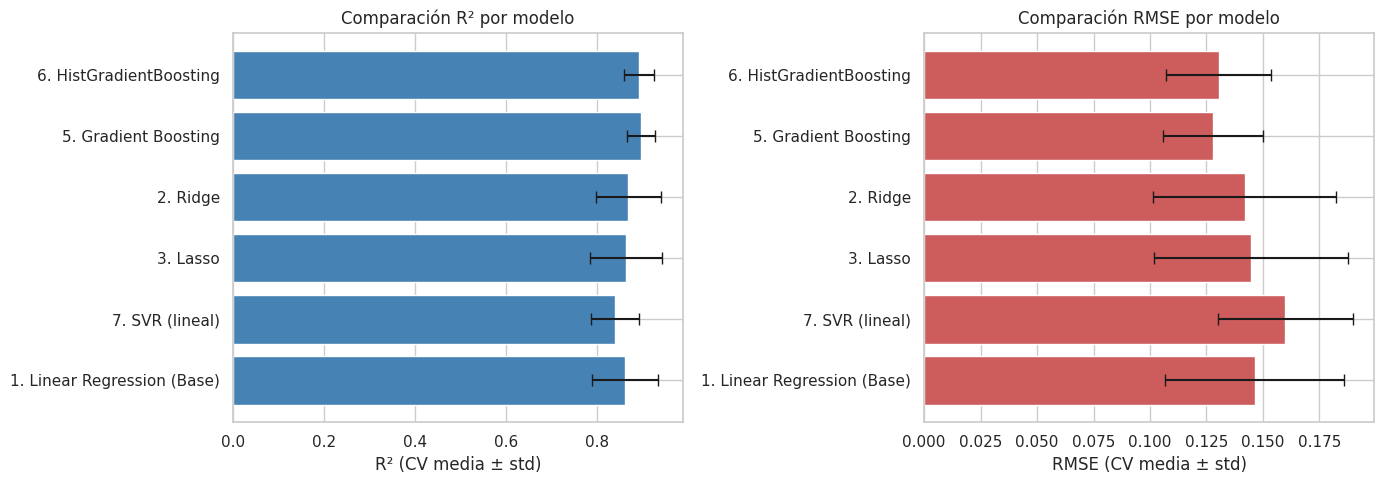

In [117]:
# Ordenar df_resultados con el mismo criterio que la tabla
df_plot = df_resultados.sort_values("R2_test", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- R² CV ---
axes[0].barh(
    df_plot["Modelo"], df_plot["CV_R2_mean"],
    xerr=df_plot["CV_R2_std"], capsize=4, color="steelblue"
)
axes[0].set_xlabel("R² (CV media ± std)")
axes[0].set_title("Comparación R² por modelo")
axes[0].invert_yaxis()

# --- RMSE CV ---
axes[1].barh(
    df_plot["Modelo"], df_plot["CV_RMSE_mean"],
    xerr=df_plot["CV_RMSE_std"], capsize=4, color="indianred"
)
axes[1].set_xlabel("RMSE (CV media ± std)")
axes[1].set_title("Comparación RMSE por modelo")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

#### Prediccion vs Real

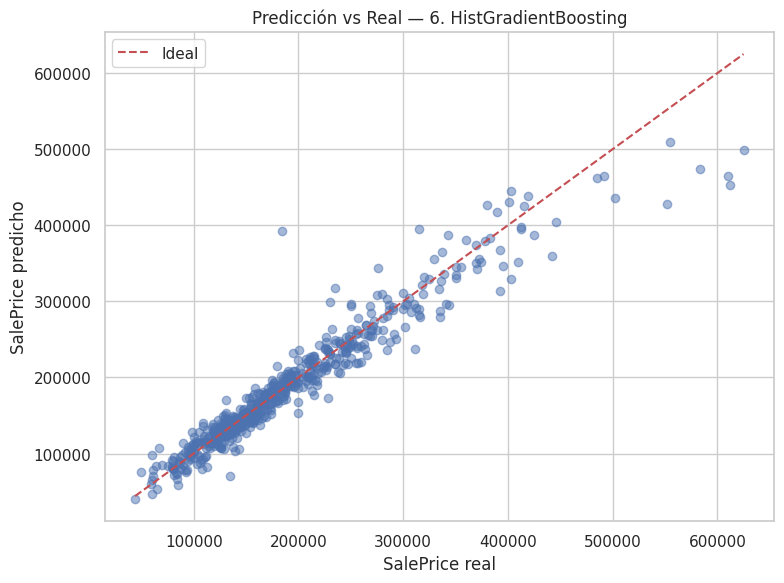

RMSE (USD): 23,950.86
MAE  (USD): 14,481.03
R²   (USD): 0.9285


In [124]:
mejor_modelo_nombre = df_resultados.iloc[0]["Modelo"]

y_pred_mejor = predicciones[mejor_modelo_nombre]
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_mejor)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_orig, y_pred_orig, alpha=0.5)
lims = [y_test_orig.min(), y_test_orig.max()]
plt.plot(lims, lims, "r--", label="Ideal")
plt.xlabel("SalePrice real")
plt.ylabel("SalePrice predicho")
plt.title(f"Predicción vs Real — {mejor_modelo_nombre}")
plt.legend()
plt.tight_layout()
plt.show()

# Métricas en escala original de dólares
print(f"RMSE (USD): {np.sqrt(mean_squared_error(y_test_orig, y_pred_orig)):,.2f}")
print(f"MAE  (USD): {mean_absolute_error(y_test_orig, y_pred_orig):,.2f}")
print(f"R²   (USD): {r2_score(y_test_orig, y_pred_orig):.4f}")

#### Analisis y conclusiones

| Columna | Qué mide | Qué buscar |
|---|---|---|
| **R² (CV) ± std** | Varianza explicada promedio en 5 folds | Mayor media y **menor std** (estabilidad) |
| **RMSE (CV) ± std** | Error típico en log-precio | Menor media y menor std |
| **R² (Test)** | Varianza explicada en el holdout | Similar al CV → no overfit |
| **RMSE (Test)** | Error en el set aislado | Cercano al CV |
| **MAE (Test)** | Error absoluto medio | Robusto a outliers |

**Reglas de decisión:**

- Si `R² (Test) ≪ R² (CV)` → **overfitting** → reducir complejidad, más regularización, `min_samples_leaf` más alto.
- Si ambos son bajos → **underfitting** → más features, más profundidad, menos regularización.
- El **std** del CV es tan importante como la media: un modelo con `0.88 ± 0.005` es mejor que uno con `0.89 ± 0.05`.

---

#### Flujo

```
┌────────────────────┐
│ Feature engineering│  Age, Remod_Age, Total_SF, Total_Bath,
│ (df_fe)            │  Porch_SF, ordinales, Qual_x_TotalSF, Cond_x_Age
└─────────┬──────────┘
          │
┌─────────▼──────────┐
│ Split              │  X_train/X_test, y = log1p(SalePrice)
└─────────┬──────────┘
          │
┌─────────▼──────────┐
│ Preprocessing      │  ColumnTransformer:
│ (dentro Pipeline)  │  num → imputer(median) + scaler
│                    │  cat → imputer(None) + onehot
└─────────┬──────────┘
          │
┌─────────▼──────────┐
│ HalvingRandomSearch│  cv=5, factor=3, n_candidates=exhaustive
│ + Pipeline         │  scoring='r2', refit=True
└─────────┬──────────┘
          │
┌─────────▼──────────┐
│ Evaluación         │  cross_val_score (R² y RMSE) → mean ± std
│                    │  test → R², RMSE, MAE
└─────────┬──────────┘
          │
┌─────────▼──────────┐
│ Tabla comparativa  │  Modelo | R²(CV)±std | RMSE(CV)±std |
│                    │  R²(Test) | RMSE(Test) | MAE(Test)
└────────────────────┘
```

## Flujo de producción recomendado (recordatorio)

Basado en lo que pide tu tabla original de mitigación de errores:

1. **Baseline** → `LinearRegression` o `DummyRegressor`.  
2. **Exploración rápida** → `RandomizedSearchCV` con pocos `n_iter`.  
3. **Refinamiento** → `HalvingRandomSearchCV` (o `BayesSearchCV` si cada evaluación es costosa).  
4. **Validación final** → test set aislado.  
5. **Preprocessing siempre dentro del `Pipeline`** para evitar data leakage.  
6. **Monitoreo** → R², RMSE, MAE y deriva de datos.
